# Noise-Space Posterior Sampling (NSPS) — 2D Proof-of-Concept

```
log p(eps|y) = -0.5 ||eps||^2  -  0.5 ||y - A(D(G(eps)))||^2 / sigma^2
               ^^^^^^^^^^^^^^^    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
               N(0,I)!            Backprop through flow INVERSE + decoder
                                  BiFlow IS the flow inverse 
```

## Pipeline
```
eps ~ N(0,I) --[flow.inverse / BiFlow]--> z --[Decoder]--> x --[Forward A]--> y_pred
```

In [1]:
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

sys.path.insert(0, '.')

from flow_model import RealNVP, train_flow, verify_flow
from log_posterior import LogPosterior
from forward_models import (
    sample_gaussian_mixture, log_prob_gaussian_mixture,
    identity_decoder, make_partial_observation, make_noisy_observation,
)
from samplers import HMCSampler, NUTSSampler, compute_ess, compute_rhat, run_multi_chain
from validation import (
    compute_analytical_posterior_grid, coverage_test,
    posterior_summary, mcmc_health_check,
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

torch.manual_seed(42)
np.random.seed(42)

# Consistent axis limits for all 2D scatter plots
ZLIM = (-4.5, 4.5)

Device: cpu


---
## Step 1: Train the Flow

In [2]:
target_samples = sample_gaussian_mixture(20000, n_components=4, std=0.3, device=device)

flow = RealNVP(dim=2, hidden_dim=64, n_layers=8).to(device)
losses = train_flow(flow, target_samples, n_epochs=2000, lr=1e-3)

print("\n=== Flow Verification ===")
verify_flow(flow)

Epoch 200/2000, NLL: 1.8543
Epoch 400/2000, NLL: 1.8422
Epoch 600/2000, NLL: 1.8313
Epoch 800/2000, NLL: 1.8236
Epoch 1000/2000, NLL: 1.8157
Epoch 1200/2000, NLL: 1.8127
Epoch 1400/2000, NLL: 1.8099
Epoch 1600/2000, NLL: 1.8045
Epoch 1800/2000, NLL: 1.8068
Epoch 2000/2000, NLL: 1.8024

=== Flow Verification ===
  Max invertibility error: 7.46e-05
  Sample mean: [0.013, 0.008]
  Sample std:  [1.460, 1.424]
  Flow verification PASSED


{'max_error': 7.462501525878906e-05,
 'mean': tensor([0.0128, 0.0078]),
 'std': tensor([1.4598, 1.4243]),
 'ok': True}

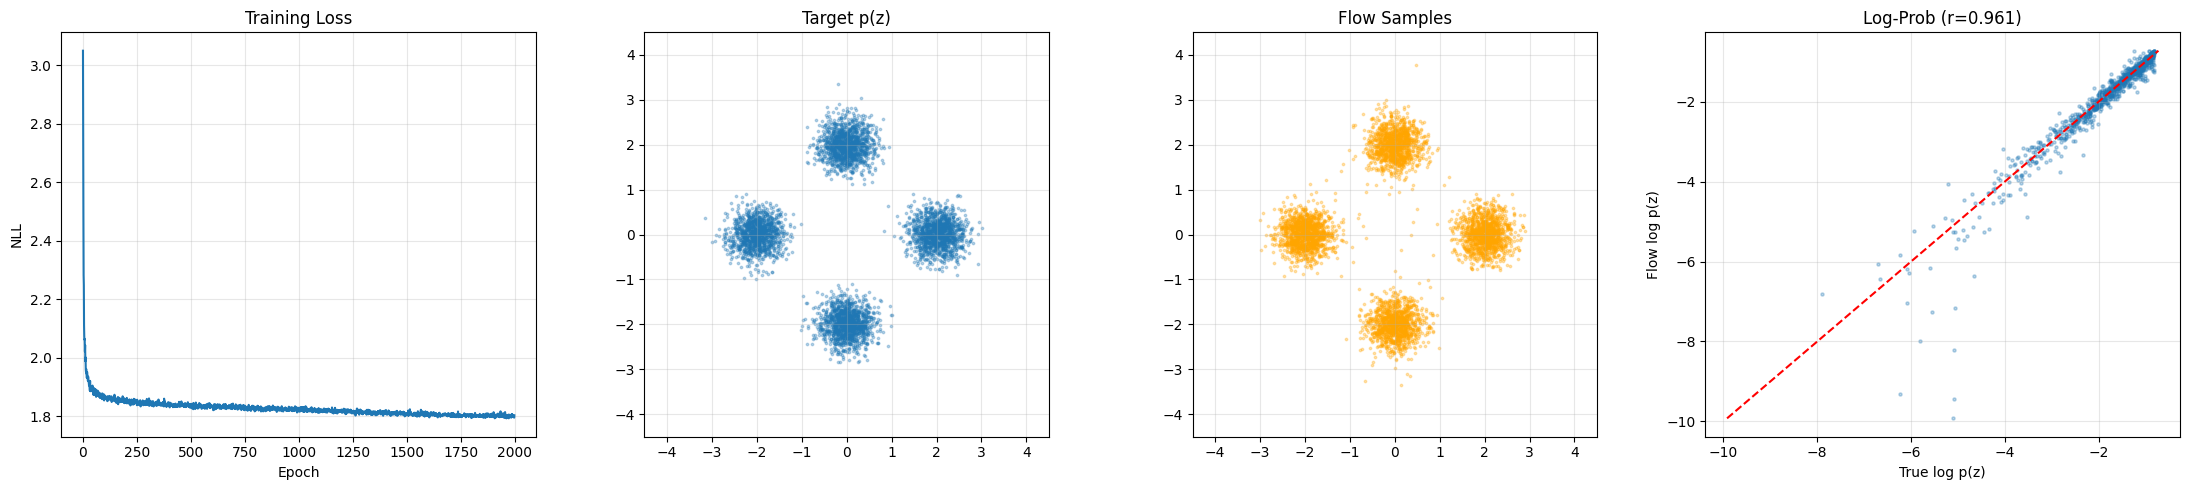

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

axes[0].plot(losses)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('NLL')
axes[0].set_title('Training Loss'); axes[0].grid(True, alpha=0.3)

with torch.no_grad():
    flow_samples = flow.sample(5000).cpu().numpy()
target_np = target_samples[:5000].cpu().numpy()

axes[1].scatter(target_np[:, 0], target_np[:, 1], alpha=0.3, s=3)
axes[1].set_title('Target p(z)'); axes[1].set_aspect('equal')
axes[1].set_xlim(*ZLIM); axes[1].set_ylim(*ZLIM); axes[1].grid(True, alpha=0.3)

axes[2].scatter(flow_samples[:, 0], flow_samples[:, 1], alpha=0.3, s=3, c='orange')
axes[2].set_title('Flow Samples'); axes[2].set_aspect('equal')
axes[2].set_xlim(*ZLIM); axes[2].set_ylim(*ZLIM); axes[2].grid(True, alpha=0.3)

test_z = sample_gaussian_mixture(1000, n_components=4, std=0.3, device=device)
with torch.no_grad():
    lp_flow = flow.log_prob(test_z).cpu().numpy()
    lp_true = log_prob_gaussian_mixture(test_z).cpu().numpy()
axes[3].scatter(lp_true, lp_flow, alpha=0.3, s=5)
lims = [min(lp_true.min(), lp_flow.min()), max(lp_true.max(), lp_flow.max())]
axes[3].plot(lims, lims, 'r--')
axes[3].set_xlabel('True log p(z)'); axes[3].set_ylabel('Flow log p(z)')
axes[3].set_title(f'Log-Prob (r={np.corrcoef(lp_true, lp_flow)[0,1]:.3f})')
axes[3].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

---
## Step 2: Set Up Inverse Problem

In [4]:
A = torch.tensor([[1.0, 0.0]], device=device)
forward_op = make_partial_observation(A)
decoder = identity_decoder
sigma_n = 0.1

idx = torch.randint(0, len(target_samples), (1,)).item()
z_true = target_samples[idx]
y_obs = make_noisy_observation(forward_op, z_true, sigma_n, seed=123)

print(f'Ground truth z: {z_true.cpu().numpy()}')
print(f'Observation y:  {y_obs.cpu().numpy()}')
print(f'sigma_n:        {sigma_n}')

Ground truth z: [ 0.06819414 -2.3271177 ]
Observation y:  [0.05704742]
sigma_n:        0.1


---
## Step 3: Compute Analytical Posterior (Ground Truth for Validation)

Since we know the flow's `log_prob(z)` and the likelihood is Gaussian, we can compute the **exact** posterior on a grid. This is our gold standard for validation.

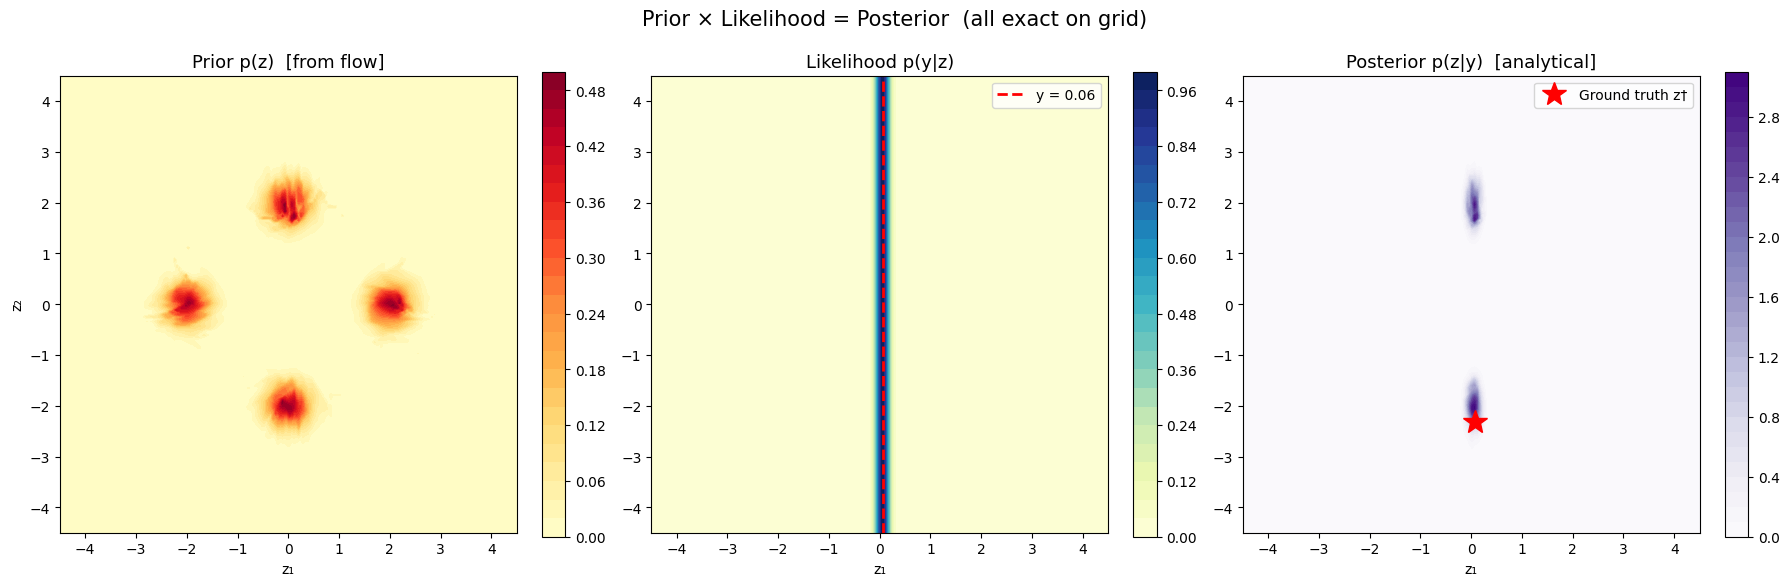

In [5]:
analytical = compute_analytical_posterior_grid(
    flow, forward_op, y_obs, sigma_n, A,
    grid_range=(-4.5, 4.5), grid_size=200, device=device,
)

# Show the analytical posterior with prior and likelihood
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
xx, yy = analytical['xx'], analytical['yy']

# Prior
im0 = axes[0].contourf(xx, yy, np.exp(analytical['log_prior']), levels=30, cmap='YlOrRd')
axes[0].set_title('Prior p(z)  [from flow]', fontsize=13)
axes[0].set_xlabel('z₁'); axes[0].set_ylabel('z₂')
axes[0].set_aspect('equal'); plt.colorbar(im0, ax=axes[0], fraction=0.046)

# Likelihood
ll = analytical['log_likelihood']
im1 = axes[1].contourf(xx, yy, np.exp(ll - ll.max()), levels=30, cmap='YlGnBu')
axes[1].axvline(x=y_obs.cpu().item(), color='red', linestyle='--', lw=2,
                label=f'y = {y_obs.cpu().item():.2f}')
axes[1].set_title('Likelihood p(y|z)', fontsize=13)
axes[1].set_xlabel('z₁'); axes[1].legend(fontsize=10)
axes[1].set_aspect('equal'); plt.colorbar(im1, ax=axes[1], fraction=0.046)

# Posterior
im2 = axes[2].contourf(xx, yy, analytical['posterior'], levels=30, cmap='Purples')
axes[2].plot(*z_true.cpu().numpy(), 'r*', markersize=18, label='Ground truth z†')
axes[2].set_title('Posterior p(z|y)  [analytical]', fontsize=13)
axes[2].set_xlabel('z₁'); axes[2].legend(fontsize=10)
axes[2].set_aspect('equal'); plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.suptitle('Prior × Likelihood = Posterior  (all exact on grid)', fontsize=15, y=1.02)
plt.tight_layout(); plt.show()

---
## Step 4: Build Log-Posterior in Epsilon-Space & Run HMC

Using HMC (simpler, more robust than NUTS) as the primary sampler.

In [6]:
# Build log-posterior in eps-space
flow_inverse = lambda eps: flow.inverse(eps.unsqueeze(0)).squeeze(0)

log_posterior = LogPosterior(
    flow_inverse=flow_inverse,
    decoder=decoder,
    forward_op=forward_op,
    y=y_obs,
    sigma_n=sigma_n,
)

# Verify gradient
eps_test = torch.randn(2, device=device)
val, grad = log_posterior.value_and_grad(eps_test)
print(f'log p(eps|y) = {val.item():.4f}')
print(f'grad = {grad.cpu().numpy()}')
assert torch.all(torch.isfinite(grad)), 'Non-finite gradient!'
print('Gradient check PASSED')

log p(eps|y) = -0.3296
grad = [ 1.1721551 -1.6944965]
Gradient check PASSED


In [7]:
# Initialize: map z guess -> eps-space
z_init_guess = torch.zeros(2, device=device)
z_init_guess[0] = y_obs.squeeze()
with torch.no_grad():
    eps_init, _ = flow.forward(z_init_guess.unsqueeze(0))
    eps_init = eps_init.squeeze(0)

print(f'Initialization: z_guess={z_init_guess.cpu().numpy()} -> eps_init={eps_init.cpu().numpy()}')

Initialization: z_guess=[0.05704742 0.        ] -> eps_init=[0.08538602 0.9140905 ]


In [ ]:
# ---- Annealed HMC: anneal sigma from 2.0 → 0.1 to escape mode traps ----
from samplers import run_annealed_hmc

# sigma_t^2 absorbed into sigma_n:  sigma_eff = sqrt(sigma_n^2 + sigma_t^2)
# Start broad (sigma=2.0), end at the true noise level (sigma=0.1)
sigma_schedule = [2.0, 1.0, 0.5, 0.25, 0.1]
sigma_schedule = [0.57, 0.56, 0.5, 0.54, 0.53]

def log_posterior_factory(sigma_eff):
    return LogPosterior(
        flow_inverse=flow_inverse,
        decoder=decoder,
        forward_op=forward_op,
        y=y_obs,
        sigma_n=sigma_eff,
    )

annealed = run_annealed_hmc(
    log_posterior_factory=log_posterior_factory,
    eps_init=eps_init,
    sigma_schedule=sigma_schedule,
    n_samples_per_stage=300,
    n_warmup_per_stage=300,
    n_leapfrog=20,
    verbose=True,
)

# Final samples are at the true sigma_n
eps_annealed = annealed['final_samples']
with torch.no_grad():
    z_annealed = flow.inverse(eps_annealed).cpu().numpy()



  Stage 1/5: sigma_eff=0.7000
  Auto step size: 0.500000


HMC:  51%|█████     | 306/600 [00:05<00:04, 60.09it/s]

  Adapted step size: 0.017023


HMC: 100%|██████████| 600/600 [00:10<00:00, 59.22it/s]


    acceptance=0.753  step=0.01702  ESS=[11, 13]

  Stage 2/5: sigma_eff=0.6000
  Auto step size: 0.099714


...

    acceptance=0.692  step=0.04131  ESS=[42, 45]

  Stage 5/5: sigma_eff=0.3000
  Auto step size: 0.254706


HMC:  52%|█████▏    | 311/600 [00:05<00:04, 59.80it/s]

  Adapted step size: 0.044444


HMC: 100%|██████████| 600/600 [00:10<00:00, 58.37it/s]

    acceptance=0.665  step=0.04444  ESS=[29, 38]


In [9]:
# Run HMC
# - step_size=None: auto-detect via dual averaging
# - n_leapfrog=50: longer trajectories compensate for the small adapted step sizes
#   (flow inverse has sharp curvature → step sizes adapt to ~0.01)
hmc = HMCSampler(log_posterior, dim=2, step_size=None, n_leapfrog=50)
eps_samples, info = hmc.sample(
    eps_init, n_samples=2000, n_warmup=500, verbose=True,
)

# Map to z-space
with torch.no_grad():
    z_samples = flow.inverse(eps_samples).cpu().numpy()

eps_np = eps_samples.cpu().numpy()
z_true_np = z_true.cpu().numpy()

print(f'\nPosterior mean (z): {z_samples.mean(axis=0)}')
print(f'Ground truth z:     {z_true_np}')

  Auto step size: 0.003906


HMC:  20%|██        | 505/2500 [00:20<01:19, 25.10it/s]

  Adapted step size: 0.021315


HMC: 100%|██████████| 2500/2500 [01:41<00:00, 24.51it/s]


Posterior mean (z): [0.05201753 1.9859093 ]
Ground truth z:     [ 0.06819414 -2.3271177 ]


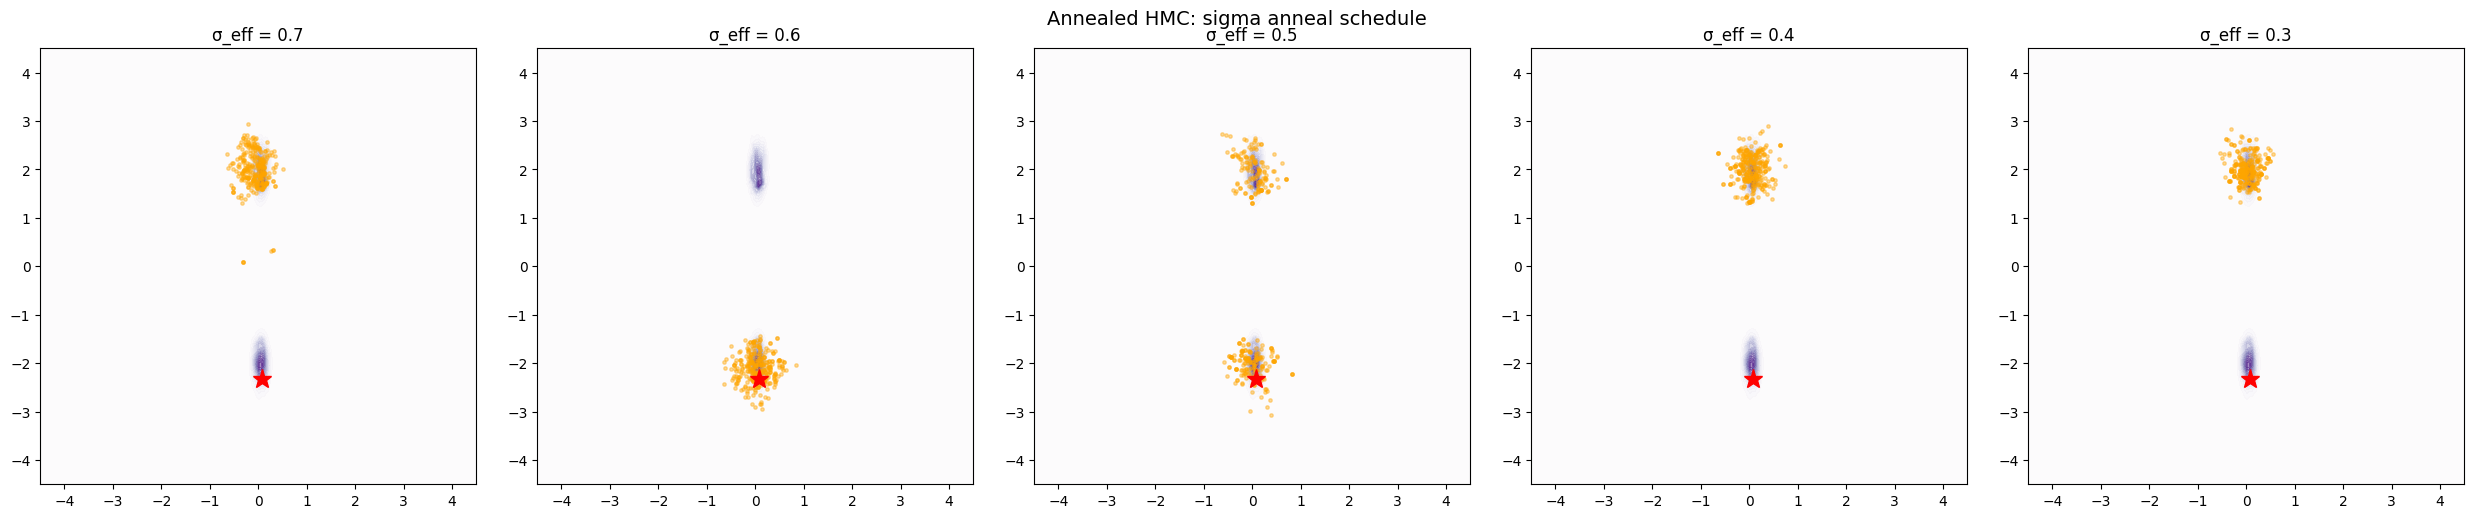

In [10]:
fig, axes = plt.subplots(1, len(sigma_schedule), figsize=(5*len(sigma_schedule), 5))

for i, (sigma_eff, stage_eps) in enumerate(
        zip(sigma_schedule, annealed['all_stage_samples'])):
    with torch.no_grad():
        stage_z = flow.inverse(stage_eps).cpu().numpy()
    axes[i].contourf(xx, yy, analytical['posterior'], levels=20, cmap='Purples', alpha=0.5)
    axes[i].scatter(stage_z[:, 0], stage_z[:, 1], alpha=0.4, s=6, c='orange')
    axes[i].plot(*z_true_np, 'r*', markersize=14)
    axes[i].set_title(f'σ_eff = {sigma_eff}')
    axes[i].set_xlim(*ZLIM); axes[i].set_ylim(*ZLIM); axes[i].set_aspect('equal')

plt.suptitle('Annealed HMC: sigma anneal schedule', fontsize=14)
plt.tight_layout(); plt.show()

---
## Step 5: Validate the Posterior

Three checks:
1. **Visual**: do MCMC samples match the analytical posterior contours?
2. **Coverage**: are credible regions calibrated? (reliability diagram)
3. **MCMC health**: ESS, acceptance rate, step size, divergences

In [11]:
# MCMC health check
checks = mcmc_health_check(eps_samples, info)

MCMC HEALTH CHECK
  [PASS] Acceptance rate: 0.678  (target: [0.40, 0.95])
  [PASS] Step size: 0.021315  (sanity: (1e-5, 5.0))
  [PASS] ESS (min): 534.6  (target: > 50)
  [PASS] Divergences: 0  (target: 0)

  ALL CHECKS PASSED


In [12]:
# Posterior summary
metrics = posterior_summary(z_samples, z_true, analytical)

POSTERIOR QUALITY SUMMARY
  Ground truth:    [0.068, -2.327]
  Posterior mean:  [0.052, 1.986]
  Posterior std:   [0.092, 0.292]
  Error:           [-0.016, 4.313]
  Truth within 2σ: False
  Analytical posterior modes: 2


In [13]:
# Coverage test
cov = coverage_test(z_samples, analytical)
print(f"\nCoverage test:")
print(f"  KS statistic:     {cov['ks_statistic']:.4f}  (< 0.10 = good)")
print(f"  KS p-value:       {cov['ks_pvalue']:.4f}")
print(f"  Calibration error: {cov['calibration_error']:.4f}")
print(f"  Calibrated:       {cov['is_calibrated']}")


Coverage test:
  KS statistic:     0.0410  (< 0.10 = good)
  KS p-value:       0.0024
  Calibration error: 0.0151
  Calibrated:       True


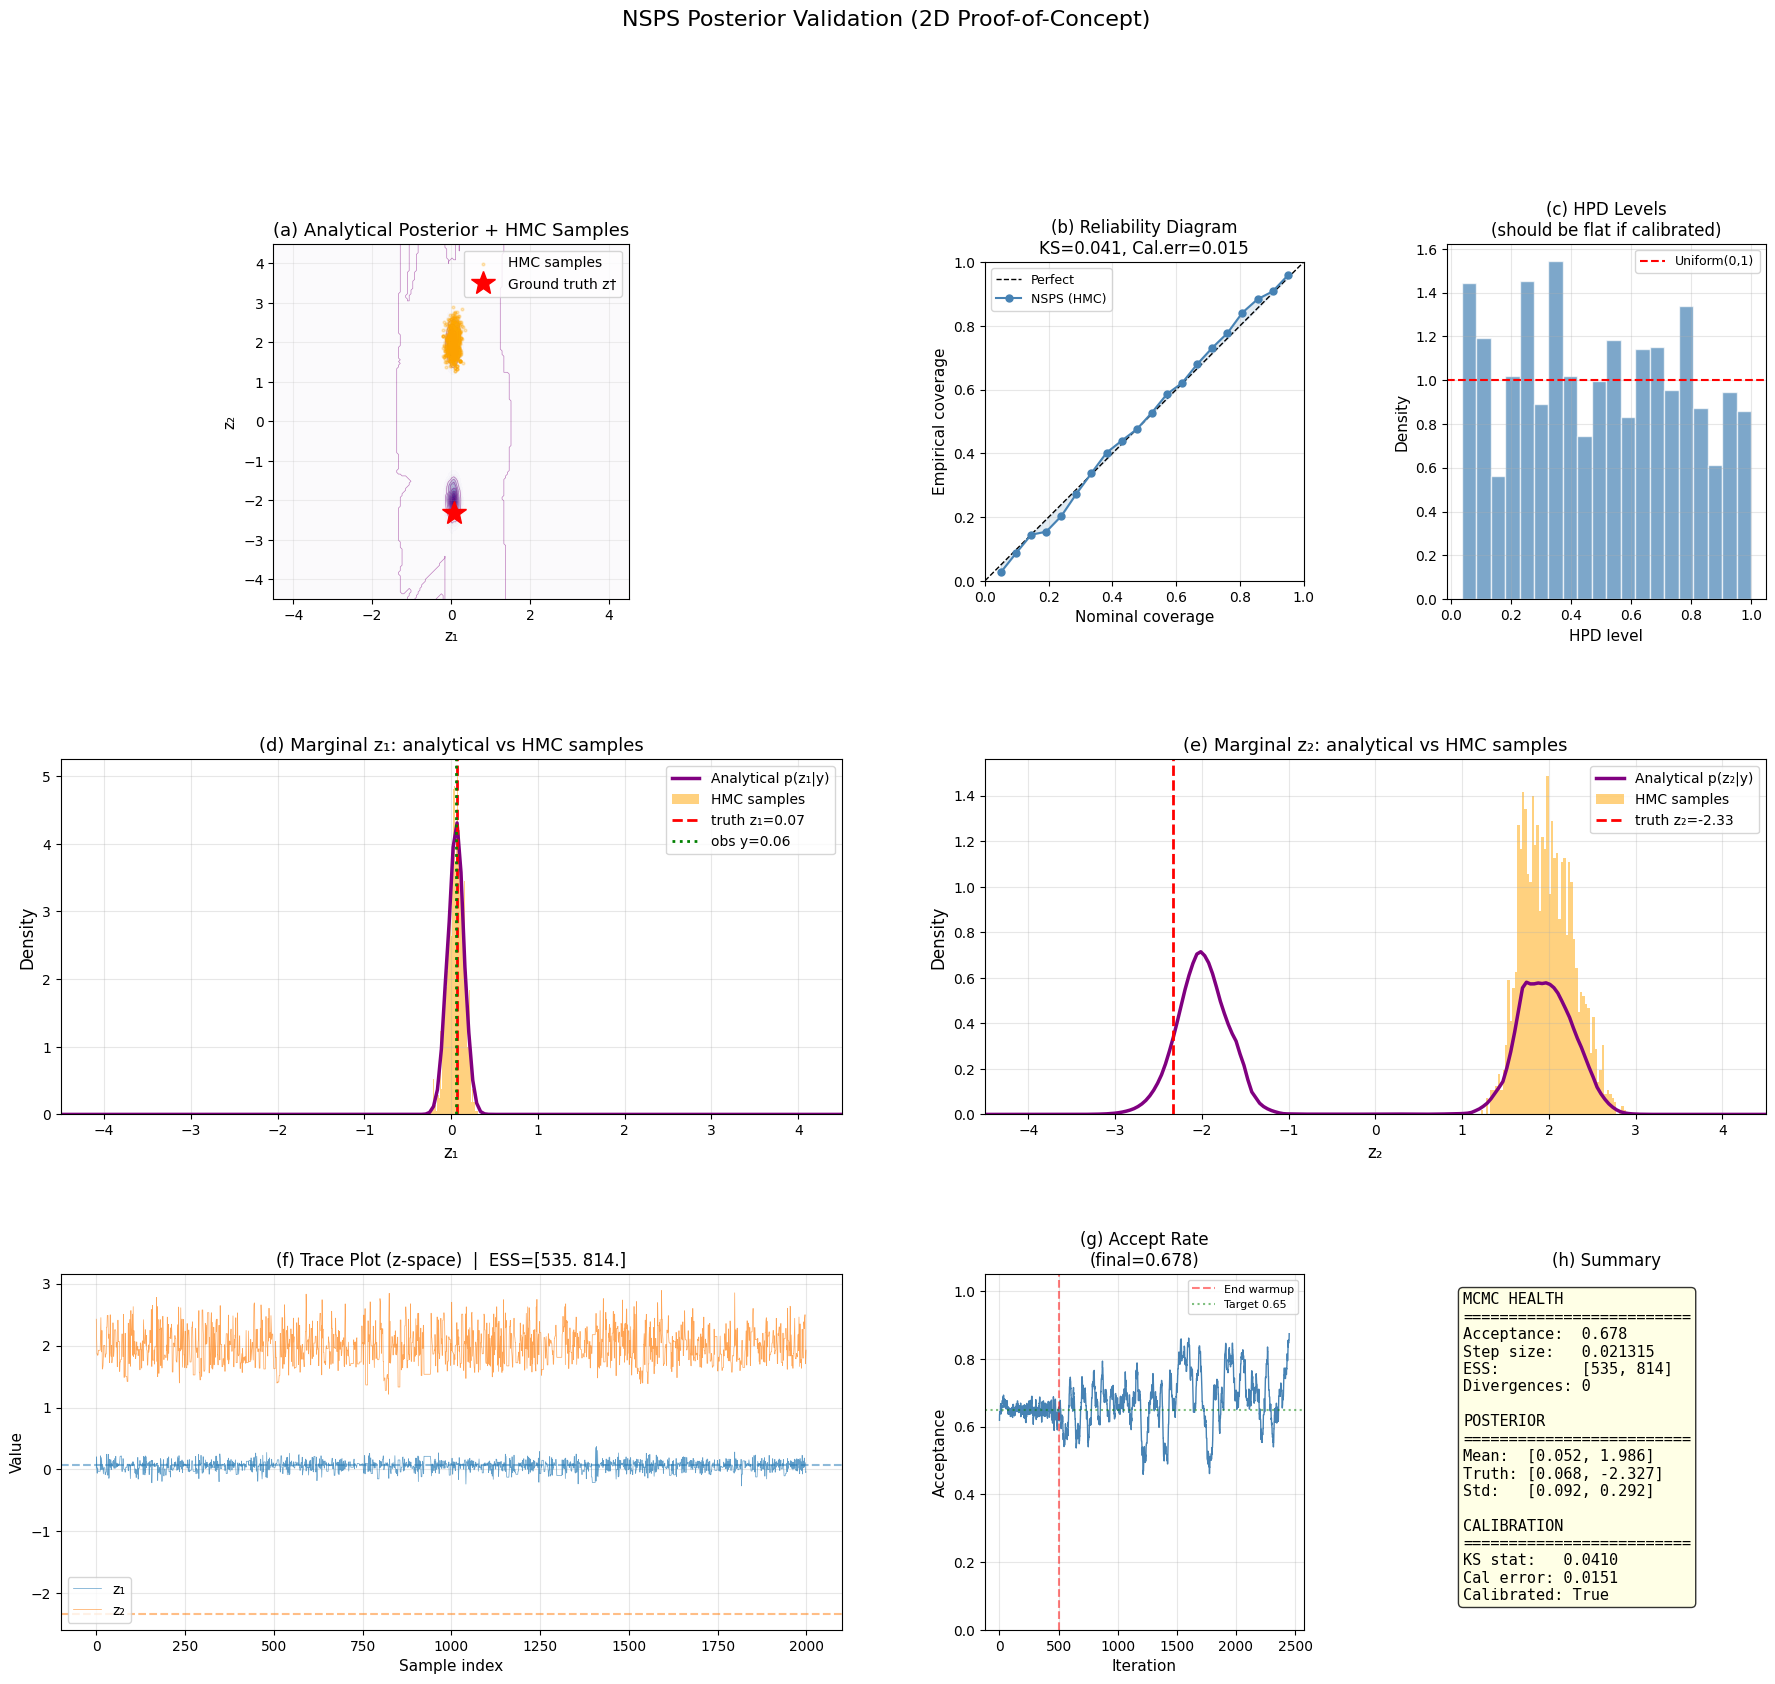

Saved: nsps_validation.png


In [14]:
# === BIG VALIDATION FIGURE ===
fig = plt.figure(figsize=(22, 18))
gs = GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.45)

# ---- Row 1: Analytical posterior + MCMC overlay ----

# (a) Analytical posterior with MCMC samples overlaid
ax = fig.add_subplot(gs[0, 0:2])
ax.contourf(xx, yy, analytical['posterior'], levels=30, cmap='Purples', alpha=0.8)
ax.contour(xx, yy, analytical['posterior'], levels=8, colors='purple',
           linewidths=0.5, alpha=0.5)
ax.scatter(z_samples[::2, 0], z_samples[::2, 1], alpha=0.25, s=4, c='orange',
           label='HMC samples', zorder=3)
ax.plot(*z_true_np, 'r*', markersize=18, zorder=5, label='Ground truth z†')
ax.set_title('(a) Analytical Posterior + HMC Samples', fontsize=13)
ax.set_xlabel('z₁', fontsize=11); ax.set_ylabel('z₂', fontsize=11)
ax.set_xlim(*ZLIM); ax.set_ylim(*ZLIM)
ax.set_aspect('equal'); ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.2)

# (b) Reliability diagram
ax = fig.add_subplot(gs[0, 2])
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect')
ax.plot(cov['nominal_levels'], cov['empirical_coverage'], 'o-',
        color='steelblue', ms=5, lw=1.5, label='NSPS (HMC)')
ax.fill_between(cov['nominal_levels'], cov['empirical_coverage'],
                cov['nominal_levels'], alpha=0.15, color='steelblue')
ax.set_xlabel('Nominal coverage', fontsize=11)
ax.set_ylabel('Empirical coverage', fontsize=11)
ax.set_title(f'(b) Reliability Diagram\nKS={cov["ks_statistic"]:.3f}, '
             f'Cal.err={cov["calibration_error"]:.3f}', fontsize=12)
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# (c) HPD level histogram (should be Uniform if calibrated)
ax = fig.add_subplot(gs[0, 3])
ax.hist(cov['hpd_levels'], bins=20, density=True, alpha=0.7, color='steelblue',
        edgecolor='white')
ax.axhline(y=1.0, color='red', linestyle='--', label='Uniform(0,1)')
ax.set_xlabel('HPD level', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('(c) HPD Levels\n(should be flat if calibrated)', fontsize=12)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ---- Row 2: Marginals (overlay MCMC histogram on analytical marginal) ----

# (d) z₁ marginal
ax = fig.add_subplot(gs[1, 0:2])
z1g = analytical['z1_grid']
ax.plot(z1g, analytical['z1_marginal'], 'purple', lw=2.5, label='Analytical p(z₁|y)')
ax.hist(z_samples[:, 0], bins=60, density=True, alpha=0.5, color='orange',
        label='HMC samples')
ax.axvline(x=z_true_np[0], color='red', linestyle='--', lw=2, label=f'truth z₁={z_true_np[0]:.2f}')
ax.axvline(x=y_obs.cpu().item(), color='green', linestyle=':', lw=2,
           label=f'obs y={y_obs.cpu().item():.2f}')
ax.set_xlabel('z₁', fontsize=12); ax.set_ylabel('Density', fontsize=12)
ax.set_title('(d) Marginal z₁: analytical vs HMC samples', fontsize=13)
ax.set_xlim(*ZLIM); ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

# (e) z₂ marginal
ax = fig.add_subplot(gs[1, 2:4])
z2g = analytical['z2_grid']
ax.plot(z2g, analytical['z2_marginal'], 'purple', lw=2.5, label='Analytical p(z₂|y)')
ax.hist(z_samples[:, 1], bins=60, density=True, alpha=0.5, color='orange',
        label='HMC samples')
ax.axvline(x=z_true_np[1], color='red', linestyle='--', lw=2, label=f'truth z₂={z_true_np[1]:.2f}')
ax.set_xlabel('z₂', fontsize=12); ax.set_ylabel('Density', fontsize=12)
ax.set_title('(e) Marginal z₂: analytical vs HMC samples', fontsize=13)
ax.set_xlim(*ZLIM); ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

# ---- Row 3: MCMC diagnostics ----

# (f) Trace plot in z-space
ax = fig.add_subplot(gs[2, 0:2])
ax.plot(z_samples[:, 0], alpha=0.7, linewidth=0.5, label='z₁')
ax.plot(z_samples[:, 1], alpha=0.7, linewidth=0.5, label='z₂')
ax.axhline(y=z_true_np[0], color='C0', linestyle='--', alpha=0.5)
ax.axhline(y=z_true_np[1], color='C1', linestyle='--', alpha=0.5)
ax.set_xlabel('Sample index', fontsize=11); ax.set_ylabel('Value', fontsize=11)
ax.set_title(f'(f) Trace Plot (z-space)  |  ESS={compute_ess(eps_samples).numpy().round(0)}',
             fontsize=12)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

# (g) Acceptance probability over iterations
ax = fig.add_subplot(gs[2, 2])
window = 50
acc_hist = info['accept_history']
if len(acc_hist) > window:
    rolling_acc = np.convolve(acc_hist, np.ones(window)/window, mode='valid')
    ax.plot(rolling_acc, linewidth=1, color='steelblue')
    ax.axvline(x=500, color='red', linestyle='--', alpha=0.5, label='End warmup')
ax.axhline(y=0.65, color='green', linestyle=':', alpha=0.5, label='Target 0.65')
ax.set_xlabel('Iteration', fontsize=11); ax.set_ylabel('Acceptance', fontsize=11)
ax.set_title(f'(g) Accept Rate\n(final={info["acceptance_rate"]:.3f})', fontsize=12)
ax.set_ylim(0, 1.05); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# (h) Summary box
ax = fig.add_subplot(gs[2, 3])
ax.axis('off')
ess_vals = compute_ess(eps_samples)
summary_text = (
    f"MCMC HEALTH\n"
    f"{'='*25}\n"
    f"Acceptance:  {info['acceptance_rate']:.3f}\n"
    f"Step size:   {info['adapted_step_size']:.6f}\n"
    f"ESS:         [{ess_vals[0]:.0f}, {ess_vals[1]:.0f}]\n"
    f"Divergences: {info['n_divergences']}\n\n"
    f"POSTERIOR\n"
    f"{'='*25}\n"
    f"Mean:  [{z_samples.mean(0)[0]:.3f}, {z_samples.mean(0)[1]:.3f}]\n"
    f"Truth: [{z_true_np[0]:.3f}, {z_true_np[1]:.3f}]\n"
    f"Std:   [{z_samples.std(0)[0]:.3f}, {z_samples.std(0)[1]:.3f}]\n\n"
    f"CALIBRATION\n"
    f"{'='*25}\n"
    f"KS stat:   {cov['ks_statistic']:.4f}\n"
    f"Cal error: {cov['calibration_error']:.4f}\n"
    f"Calibrated: {cov['is_calibrated']}"
)
ax.text(0.05, 0.95, summary_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
ax.set_title('(h) Summary', fontsize=12)

fig.suptitle('NSPS Posterior Validation (2D Proof-of-Concept)', fontsize=16, y=1.01)
plt.savefig('nsps_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: nsps_validation.png')

---
## Step 6: Multi-Chain R-hat Test

In [15]:
print("=== Multi-chain HMC (4 chains) ===")
multi = run_multi_chain(
    log_posterior, eps_init,
    n_chains=4, n_warmup=500, n_samples=500,
    step_size=None, n_leapfrog=50,
    sampler_type='hmc', verbose=False,
)

# Map all chains to z-space
with torch.no_grad():
    all_eps = multi['all_samples']
    nc, ns, dd = all_eps.shape
    all_z = flow.inverse(all_eps.reshape(-1, 2)).reshape(nc, ns, dd).cpu().numpy()

=== Multi-chain HMC (4 chains) ===
  Chain 1/4...
    ESS (min): 194.6
    Acceptance rate: 0.668
    Divergences: 0
    Step size: 0.021818
  Chain 2/4...
    ESS (min): 92.9
    Acceptance rate: 0.630
    Divergences: 0
    Step size: 0.022217
  Chain 3/4...
    ESS (min): 85.2
    Acceptance rate: 0.654
    Divergences: 0
    Step size: 0.021573
  Chain 4/4...
    ESS (min): 142.6
    Acceptance rate: 0.695
    Divergences: 0
    Step size: 0.020375

  Multi-chain summary:
    R-hat: [1.0001, 1.0016]
    Combined ESS: [470.9, 831.7]
    Mean acceptance: 0.662
    Total divergences: 0


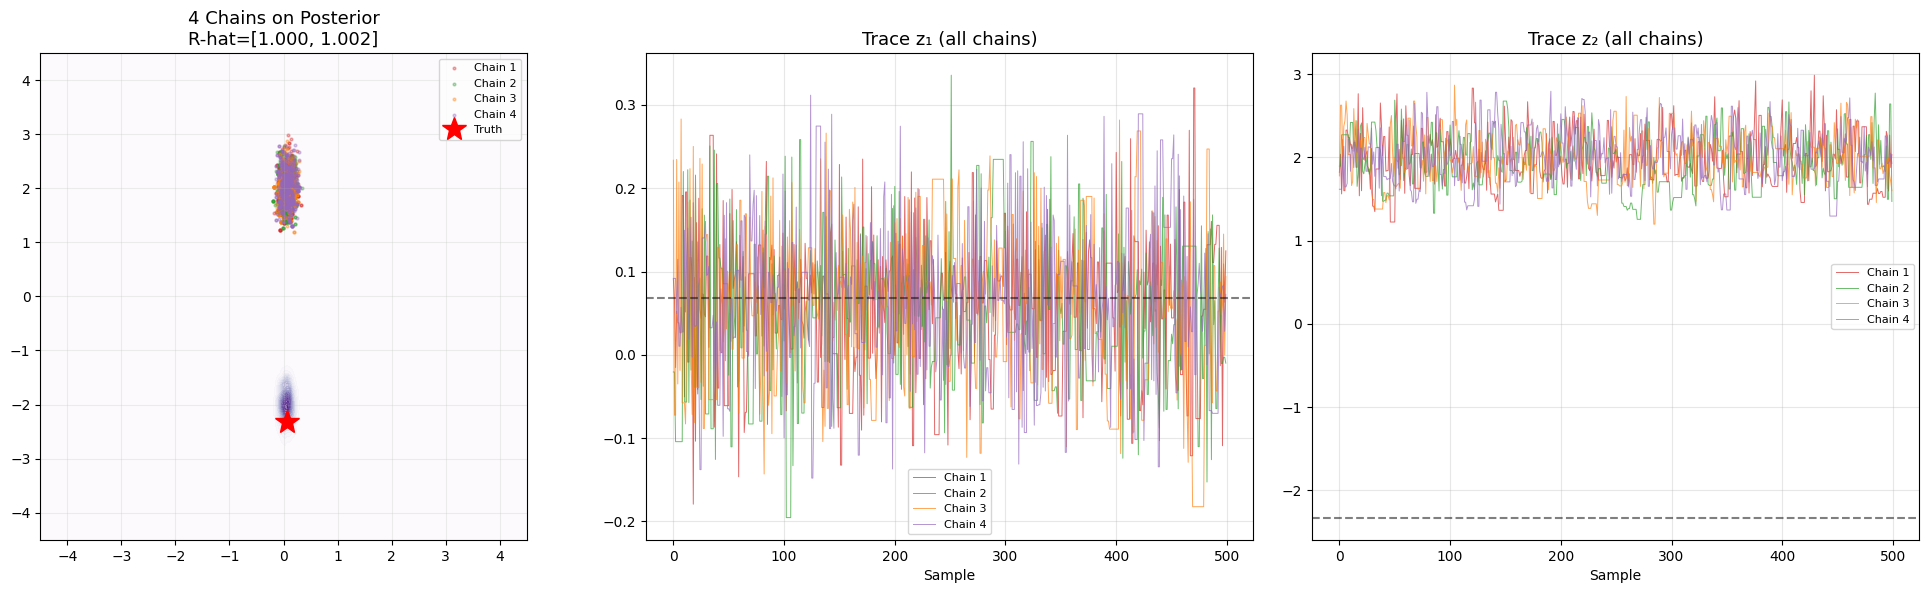

In [16]:
# Multi-chain validation plot
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
rhat = multi['rhat']

# (a) Chains overlaid on posterior
ax = axes[0]
ax.contourf(xx, yy, analytical['posterior'], levels=20, cmap='Purples', alpha=0.6)
colors = ['#d62728', '#2ca02c', '#ff7f0e', '#9467bd']
for c in range(nc):
    ax.scatter(all_z[c, :, 0], all_z[c, :, 1], alpha=0.35, s=4, c=colors[c],
              label=f'Chain {c+1}')
ax.plot(*z_true_np, 'r*', markersize=18, zorder=5, label='Truth')
ax.set_title(f'4 Chains on Posterior\nR-hat=[{rhat[0]:.3f}, {rhat[1]:.3f}]', fontsize=13)
ax.set_xlim(*ZLIM); ax.set_ylim(*ZLIM); ax.set_aspect('equal')
ax.legend(fontsize=8, loc='upper right'); ax.grid(True, alpha=0.2)

# (b) Chain trace z₁
ax = axes[1]
for c in range(nc):
    ax.plot(all_z[c, :, 0], alpha=0.7, linewidth=0.7, c=colors[c], label=f'Chain {c+1}')
ax.axhline(y=z_true_np[0], color='black', linestyle='--', alpha=0.5)
ax.set_title('Trace z₁ (all chains)', fontsize=13)
ax.set_xlabel('Sample'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# (c) Chain trace z₂
ax = axes[2]
for c in range(nc):
    ax.plot(all_z[c, :, 1], alpha=0.7, linewidth=0.7, c=colors[c], label=f'Chain {c+1}')
ax.axhline(y=z_true_np[1], color='black', linestyle='--', alpha=0.5)
ax.set_title('Trace z₂ (all chains)', fontsize=13)
ax.set_xlabel('Sample'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

---
## Step 7: Full Pipeline Visualization

Show the complete generative pipeline (top) vs posterior pipeline (bottom).

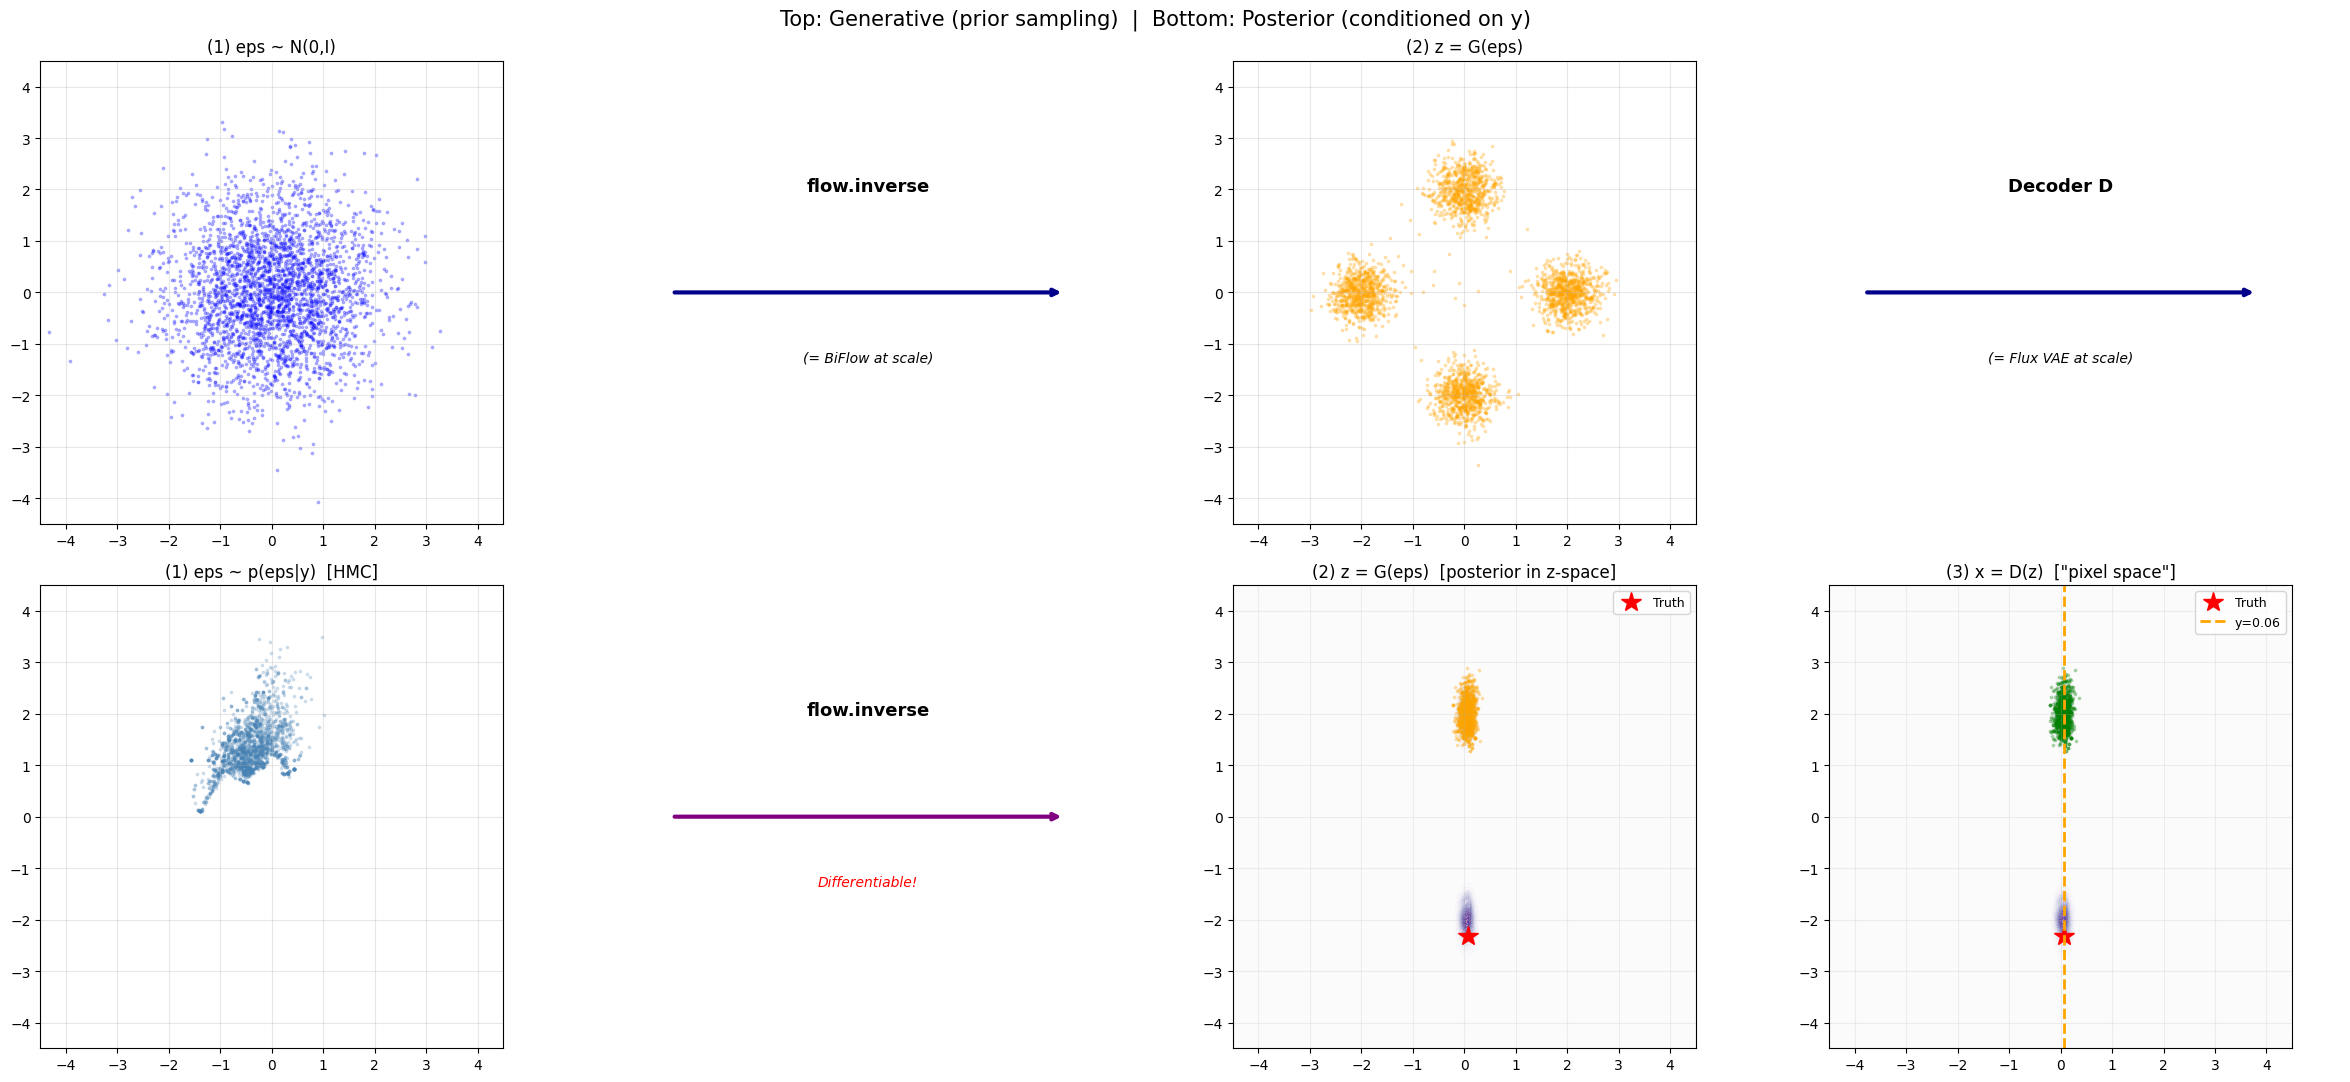

Saved: nsps_pipeline.png


In [17]:
fig, axes = plt.subplots(2, 4, figsize=(24, 11))

# --- Top row: GENERATIVE pipeline (prior sampling) ---
with torch.no_grad():
    eps_prior = torch.randn(3000, 2, device=device)
    z_prior = flow.inverse(eps_prior).cpu().numpy()
    eps_prior_np = eps_prior.cpu().numpy()

axes[0, 0].scatter(eps_prior_np[:, 0], eps_prior_np[:, 1], alpha=0.25, s=3, c='blue')
axes[0, 0].set_title('(1) eps ~ N(0,I)', fontsize=12)
axes[0, 0].set_xlim(*ZLIM); axes[0, 0].set_ylim(*ZLIM)
axes[0, 0].set_aspect('equal'); axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].annotate('', xy=(0.85, 0.5), xytext=(0.15, 0.5),
                     arrowprops=dict(arrowstyle='->', lw=3, color='darkblue'))
axes[0, 1].text(0.5, 0.72, 'flow.inverse', ha='center', fontsize=13, fontweight='bold')
axes[0, 1].text(0.5, 0.35, '(= BiFlow at scale)', ha='center', fontsize=10, style='italic')
axes[0, 1].set_xlim(0, 1); axes[0, 1].set_ylim(0, 1); axes[0, 1].axis('off')

axes[0, 2].scatter(z_prior[:, 0], z_prior[:, 1], alpha=0.25, s=3, c='orange')
axes[0, 2].set_title('(2) z = G(eps)', fontsize=12)
axes[0, 2].set_xlim(*ZLIM); axes[0, 2].set_ylim(*ZLIM)
axes[0, 2].set_aspect('equal'); axes[0, 2].grid(True, alpha=0.3)

axes[0, 3].annotate('', xy=(0.85, 0.5), xytext=(0.15, 0.5),
                     arrowprops=dict(arrowstyle='->', lw=3, color='darkblue'))
axes[0, 3].text(0.5, 0.72, 'Decoder D', ha='center', fontsize=13, fontweight='bold')
axes[0, 3].text(0.5, 0.35, '(= Flux VAE at scale)', ha='center', fontsize=10, style='italic')
axes[0, 3].set_xlim(0, 1); axes[0, 3].set_ylim(0, 1); axes[0, 3].axis('off')

# --- Bottom row: POSTERIOR pipeline ---
axes[1, 0].scatter(eps_np[:, 0], eps_np[:, 1], alpha=0.2, s=3, c='steelblue')
axes[1, 0].set_title('(1) eps ~ p(eps|y)  [HMC]', fontsize=12)
axes[1, 0].set_xlim(*ZLIM); axes[1, 0].set_ylim(*ZLIM)
axes[1, 0].set_aspect('equal'); axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].annotate('', xy=(0.85, 0.5), xytext=(0.15, 0.5),
                     arrowprops=dict(arrowstyle='->', lw=3, color='purple'))
axes[1, 1].text(0.5, 0.72, 'flow.inverse', ha='center', fontsize=13, fontweight='bold')
axes[1, 1].text(0.5, 0.35, 'Differentiable!', ha='center', fontsize=10,
                style='italic', color='red')
axes[1, 1].set_xlim(0, 1); axes[1, 1].set_ylim(0, 1); axes[1, 1].axis('off')

axes[1, 2].contourf(xx, yy, analytical['posterior'], levels=20, cmap='Purples', alpha=0.5)
axes[1, 2].scatter(z_samples[::2, 0], z_samples[::2, 1], alpha=0.25, s=3, c='orange')
axes[1, 2].plot(*z_true_np, 'r*', markersize=15, label='Truth')
axes[1, 2].set_title('(2) z = G(eps)  [posterior in z-space]', fontsize=12)
axes[1, 2].set_xlim(*ZLIM); axes[1, 2].set_ylim(*ZLIM)
axes[1, 2].set_aspect('equal'); axes[1, 2].legend(fontsize=9); axes[1, 2].grid(True, alpha=0.2)

axes[1, 3].contourf(xx, yy, analytical['posterior'], levels=20, cmap='Purples', alpha=0.5)
axes[1, 3].scatter(z_samples[::2, 0], z_samples[::2, 1], alpha=0.25, s=3, c='green')
axes[1, 3].plot(*z_true_np, 'r*', markersize=15, label='Truth')
axes[1, 3].axvline(x=y_obs.cpu().item(), color='orange', linestyle='--', lw=2,
                   label=f'y={y_obs.cpu().item():.2f}')
axes[1, 3].set_title('(3) x = D(z)  ["pixel space"]', fontsize=12)
axes[1, 3].set_xlim(*ZLIM); axes[1, 3].set_ylim(*ZLIM)
axes[1, 3].set_aspect('equal'); axes[1, 3].legend(fontsize=9); axes[1, 3].grid(True, alpha=0.2)

fig.suptitle('Top: Generative (prior sampling)  |  Bottom: Posterior (conditioned on y)',
             fontsize=15)
plt.tight_layout()
plt.savefig('nsps_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: nsps_pipeline.png')

In [18]:
# ---- Step 4b: SMC Posterior Sampling ----
from samplers import SMCSampler

# log_likelihood_fn: ONLY the likelihood term (prior is handled inside SMC)
# eps -> -0.5 * ||y - A·G(eps)||² / σ_n²
# Must support autograd (no torch.no_grad wrapper here)
def log_likelihood_fn(eps):
    z = flow_inverse(eps)
    x = decoder(z)
    pred = forward_op(x)
    return -0.5 * ((y_obs - pred) ** 2).sum() / (sigma_n ** 2)

smc = SMCSampler(
    log_likelihood_fn=log_likelihood_fn,
    dim=2,
    n_particles=300,     # more particles = better coverage
    n_mcmc_steps=5,      # HMC moves per particle per stage
    n_leapfrog=10,
    ess_threshold=0.5,
)

smc_result = smc.sample(device=device, verbose=True)

# Map eps samples back to z-space
with torch.no_grad():
    z_smc = flow.inverse(smc_result['samples']).cpu().numpy()

print(f"\nSMC: {smc_result['n_stages']} stages")
print(f"log p(y) estimate: {smc_result['log_normalizer']:.3f}")
print(f"Posterior mean (z): {z_smc.mean(axis=0)}")
print(f"Ground truth    (z): {z_true_np}")


  SMC: 300 particles, 5 HMC moves/particle/stage
  Initialising particles from prior N(0,I)...
  Stage   1: β=0.0033  Δβ=0.0033  ESS=0.90            acc=0.45  step=0.50000
  Stage   2: β=0.0078  Δβ=0.0045  ESS=0.80            acc=0.25  step=0.40000
  Stage   3: β=0.0134  Δβ=0.0057  ESS=0.71            acc=0.17  step=0.32000
  Stage   4: β=0.0242  Δβ=0.0107  ESS=0.65            acc=0.14  step=0.25600
  Stage   5: β=0.0636  Δβ=0.0394  ESS=0.60            acc=0.11  step=0.20480
  Stage   6: β=0.1212  Δβ=0.0577  ESS=0.56            acc=0.18  step=0.16384
  Stage   7: β=0.1995  Δβ=0.0783  ESS=0.51            acc=0.24  step=0.13107
  Stage   8: β=0.3082  Δβ=0.1087  ESS=0.48  RESAMPLE  acc=0.36  step=0.13107
  Stage   9: β=0.6337  Δβ=0.3255  ESS=0.90            acc=0.33  step=0.13107
  Stage  10: β=1.0000  Δβ=0.3663  ESS=0.81            acc=0.30  step=0.10486

  Done. 10 stages, log p(y) ≈ -8.113

SMC: 10 stages
log p(y) estimate: -8.113
Posterior mean (z): [0.05350138 0.06982098]
Ground trut

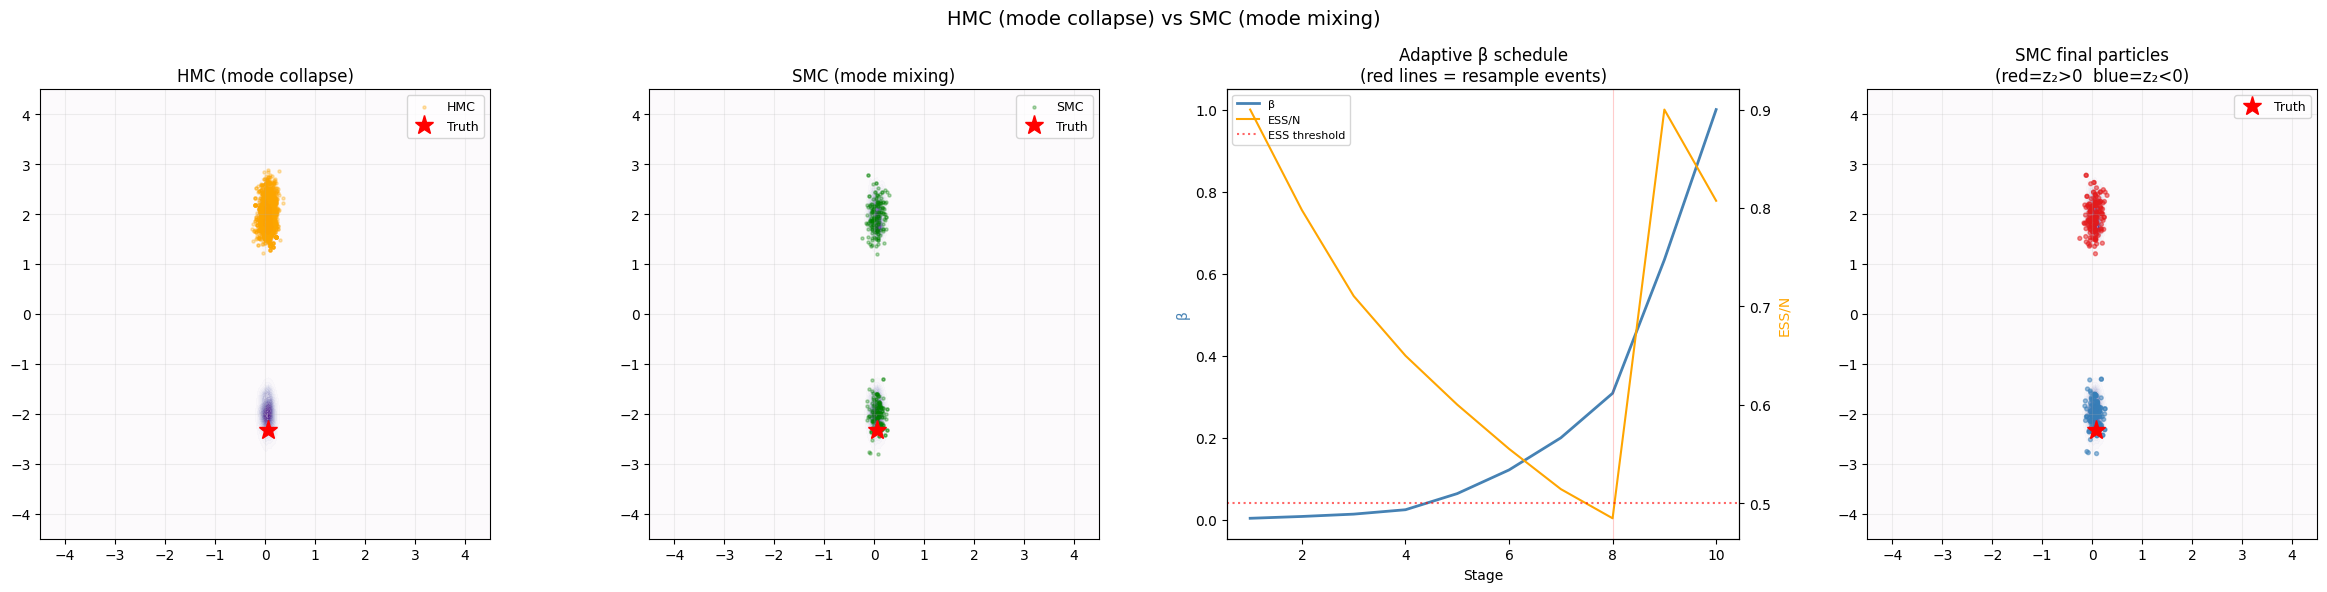

In [19]:
# ---- SMC Validation Plot ----
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

# (a) HMC samples (for comparison — shows mode collapse)
axes[0].contourf(xx, yy, analytical['posterior'], levels=20, cmap='Purples', alpha=0.6)
axes[0].scatter(z_samples[:, 0], z_samples[:, 1], alpha=0.3, s=5, c='orange', label='HMC')
axes[0].plot(*z_true_np, 'r*', markersize=14, label='Truth')
axes[0].set_title('HMC (mode collapse)', fontsize=12)
axes[0].set_xlim(*ZLIM); axes[0].set_ylim(*ZLIM); axes[0].set_aspect('equal')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.2)

# (b) SMC samples (should cover both modes)
axes[1].contourf(xx, yy, analytical['posterior'], levels=20, cmap='Purples', alpha=0.6)
axes[1].scatter(z_smc[:, 0], z_smc[:, 1], alpha=0.3, s=5, c='green', label='SMC')
axes[1].plot(*z_true_np, 'r*', markersize=14, label='Truth')
axes[1].set_title('SMC (mode mixing)', fontsize=12)
axes[1].set_xlim(*ZLIM); axes[1].set_ylim(*ZLIM); axes[1].set_aspect('equal')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.2)

# (c) SMC annealing schedule — beta vs stage
diags = smc_result['diagnostics']
betas = [d['beta'] for d in diags]
ess_fracs = [d['ess_frac'] for d in diags]
resample_stages = [d['stage'] for d in diags if d['resampled']]

ax = axes[2]
ax2 = ax.twinx()
ax.plot(range(1, len(betas)+1), betas, 'steelblue', lw=2, label='β')
ax2.plot(range(1, len(ess_fracs)+1), ess_fracs, 'orange', lw=1.5, label='ESS/N')
ax2.axhline(y=smc.ess_threshold, color='red', linestyle=':', alpha=0.6, label='ESS threshold')
for s in resample_stages:
    ax.axvline(x=s, color='red', alpha=0.2, lw=0.8)
ax.set_xlabel('Stage'); ax.set_ylabel('β', color='steelblue')
ax2.set_ylabel('ESS/N', color='orange')
ax.set_title('Adaptive β schedule\n(red lines = resample events)', fontsize=12)
lines1, labs1 = ax.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labs1+labs2, fontsize=8, loc='upper left')

# (d) Snapshots at 4 beta values to show particle evolution
snapshot_betas = [0.0, 0.1, 0.5, 1.0]
# Collect particles from prior + selected stages
# (re-run with store_intermediates=True for proper snapshots — here we just
#  show the final SMC result coloured by z2 sign as a proxy for mode)
axes[3].contourf(xx, yy, analytical['posterior'], levels=20, cmap='Purples', alpha=0.6)
colors_smc = ['#e41a1c' if z[1] > 0 else '#377eb8' for z in z_smc]
axes[3].scatter(z_smc[:, 0], z_smc[:, 1], alpha=0.5, s=8, c=colors_smc)
axes[3].plot(*z_true_np, 'r*', markersize=14, label='Truth')
axes[3].set_title('SMC final particles\n(red=z₂>0  blue=z₂<0)', fontsize=12)
axes[3].set_xlim(*ZLIM); axes[3].set_ylim(*ZLIM); axes[3].set_aspect('equal')
axes[3].legend(fontsize=9); axes[3].grid(True, alpha=0.2)

plt.suptitle('HMC (mode collapse) vs SMC (mode mixing)', fontsize=14)
plt.tight_layout(); plt.show()
